In [2]:
# This mounts your Google Drive to the Colab VM.
from google.colab import drive
drive.mount('/content/drive')
FOLDERNAME = 'MATH5470/'
assert FOLDERNAME is not None, "[!] Enter the foldername."

# Now that we've mounted your Drive, this ensures that
# the Python interpreter of the Colab VM can load
# python files from within it.
import sys
sys.path.append('/content/drive/My Drive/{}'.format(FOLDERNAME))

Mounted at /content/drive


=== Home Credit Default Risk - Random Forest Implementation ===
Features: One Standard Error Rule, Full Training Set, Progress Bars
Loading data from CSV files...
Training data shape: (307511, 125)
Test data shape: (48744, 124)

Training data columns:
['Unnamed: 0', 'SK_ID_CURR', 'TARGET', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE', 'REGION_POPULATION_RELATIVE', 'DAYS_BIRTH'] ...

Preprocessing data...
Missing values in training: 0
Missing values in test: 0
Features after preprocessing: 123
Training set shape: (307511, 123)
Test set shape: (48744, 123)

Class distribution in training: [282686  24825]
Default rate: 0.0807

Training set shape: (246008, 123)
Validation set shape: (61503, 123)
Class distribution in training set: [226148  19860]
Class distribution in validation set: [56538  4965]

Starting hyperparameter tuning with one standard error rule...
Performing hyperparameter tuning with cross-validation...
Testing 24 parameter combinations w

Grid Search:   0%|          | 0/24 [00:00<?, ?it/s]

Fitting combination 1/24, fold 1/3 with params: {'randomforest__n_estimators': 50, 'randomforest__max_depth': None, 'randomforest__min_samples_split': 2, 'randomforest__max_features': 'sqrt'}
Fitting combination 1/24, fold 2/3 with params: {'randomforest__n_estimators': 50, 'randomforest__max_depth': None, 'randomforest__min_samples_split': 2, 'randomforest__max_features': 'sqrt'}
Fitting combination 1/24, fold 3/3 with params: {'randomforest__n_estimators': 50, 'randomforest__max_depth': None, 'randomforest__min_samples_split': 2, 'randomforest__max_features': 'sqrt'}
Fitting combination 2/24, fold 1/3 with params: {'randomforest__n_estimators': 50, 'randomforest__max_depth': None, 'randomforest__min_samples_split': 2, 'randomforest__max_features': 'log2'}
Fitting combination 2/24, fold 2/3 with params: {'randomforest__n_estimators': 50, 'randomforest__max_depth': None, 'randomforest__min_samples_split': 2, 'randomforest__max_features': 'log2'}
Fitting combination 2/24, fold 3/3 with 

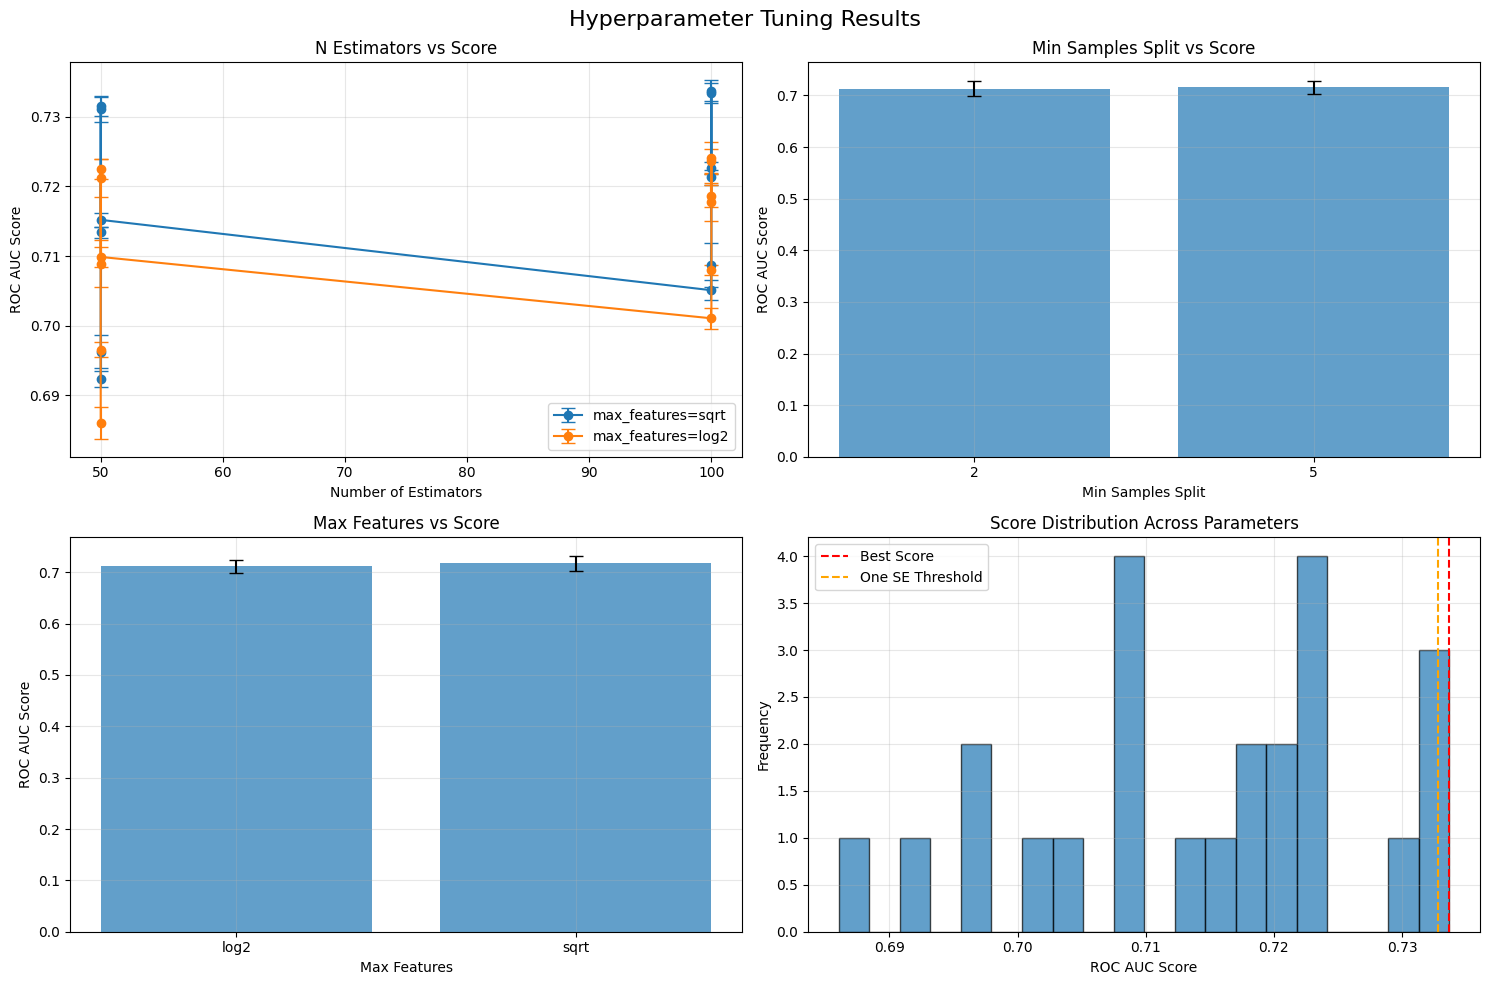


Training Final Model on Entire Training Set

Training final model on entire training set...
Fitting final model...


Final Model Training:   0%|          | 0/1 [00:00<?, ?it/s]

Final model training completed in 90.72 seconds

Final Model Evaluation on Validation Set

Evaluating model on Validation set...


Validation Prediction:   0%|          | 0/2 [00:00<?, ?it/s]

Validation Accuracy: 0.9193
Validation AUC-ROC: 0.7964

Confusion Matrix:
[[56538     0]
 [ 4965     0]]

Classification Report:
              precision    recall  f1-score   support

           0       0.92      1.00      0.96     56538
           1       0.00      0.00      0.00      4965

    accuracy                           0.92     61503
   macro avg       0.46      0.50      0.48     61503
weighted avg       0.85      0.92      0.88     61503


Generating evaluation plots...


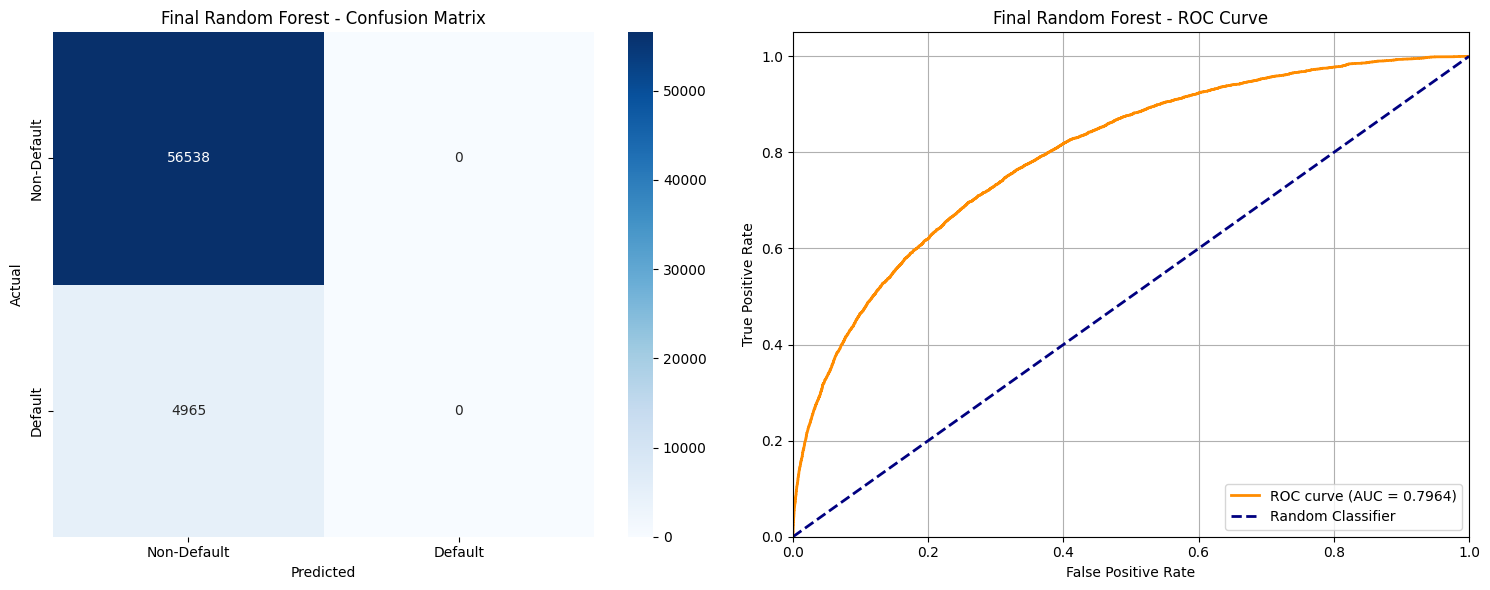


Analyzing feature importance...


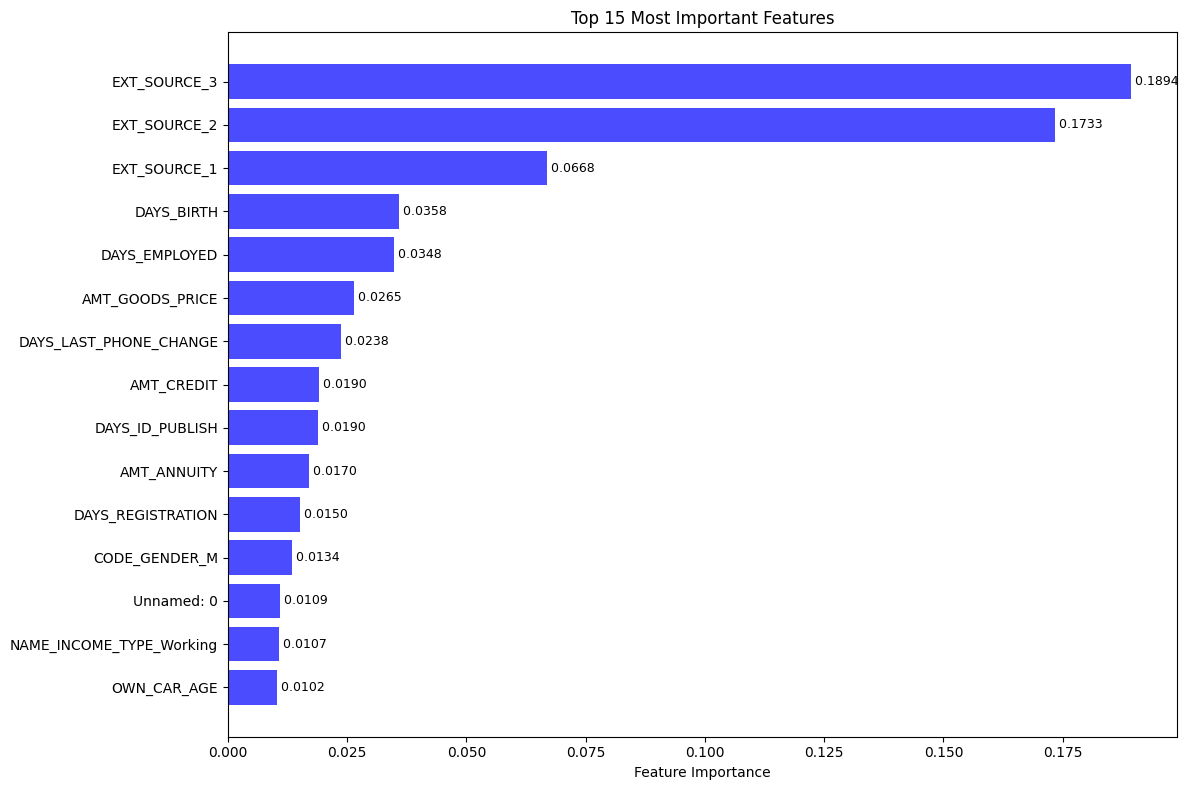


Top 15 most important features:
  EXT_SOURCE_3: 0.1894
  EXT_SOURCE_2: 0.1733
  EXT_SOURCE_1: 0.0668
  DAYS_BIRTH: 0.0358
  DAYS_EMPLOYED: 0.0348
  AMT_GOODS_PRICE: 0.0265
  DAYS_LAST_PHONE_CHANGE: 0.0238
  AMT_CREDIT: 0.0190
  DAYS_ID_PUBLISH: 0.0190
  AMT_ANNUITY: 0.0170
  DAYS_REGISTRATION: 0.0150
  CODE_GENDER_M: 0.0134
  Unnamed: 0: 0.0109
  NAME_INCOME_TYPE_Working: 0.0107
  OWN_CAR_AGE: 0.0102

Plotting importance distribution...


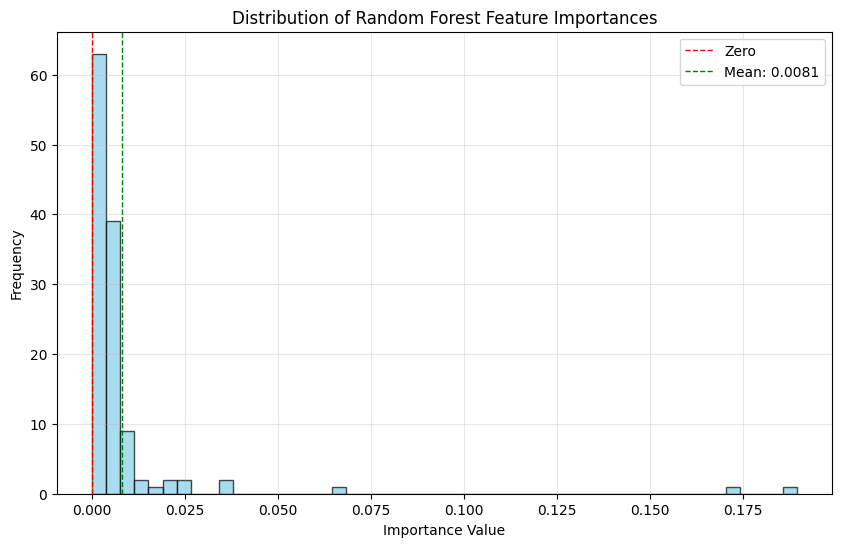

Importance Statistics:
  Min: 0.0000
  Max: 0.1894
  Mean: 0.0081
  Std: 0.0238
  Number of non-zero importances: 117

Generating Predictions for Test Set with Final Model


Test Set Prediction:   0%|          | 0/1 [00:00<?, ?it/s]

Submission file 'randomforest_final_submission.csv' created successfully!
Prediction statistics:
  Mean: 0.0811
  Std:  0.0424
  Min:  0.0176
  Max:  0.3485


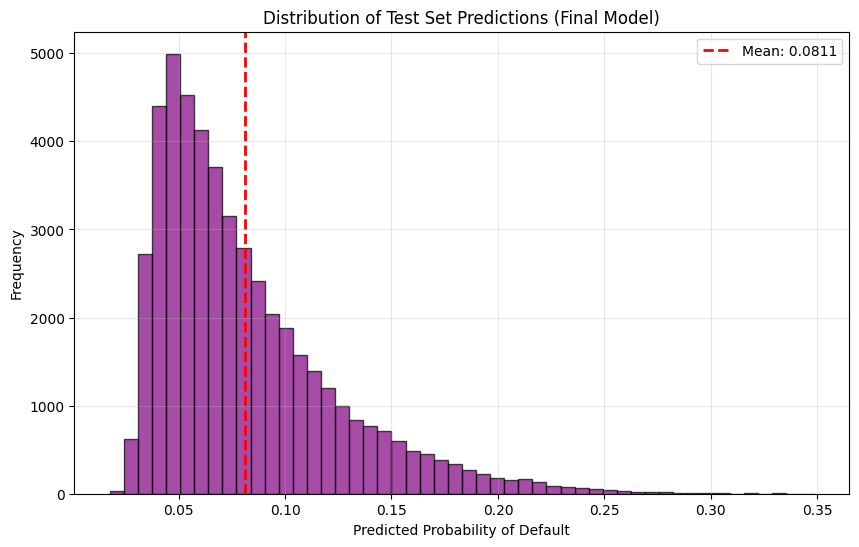


FINAL RESULTS SUMMARY
Best Parameters (One SE Rule): {'randomforest__n_estimators': 100, 'randomforest__max_depth': 10, 'randomforest__min_samples_split': 5, 'randomforest__max_features': 'sqrt'}
Validation Accuracy: 0.9193
Validation AUC-ROC: 0.7964
Number of estimators: 100
Number of features: 123

Pipeline completed successfully!


In [3]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, roc_auc_score, roc_curve, classification_report
from sklearn.pipeline import Pipeline
from sklearn.base import clone
from tqdm.auto import tqdm
import warnings
import time
import itertools
warnings.filterwarnings('ignore')

# Custom GridSearchCV with one standard error rule and proper progress bars
class GridSearchCVOneSE:
    """
    Custom GridSearchCV that implements the one standard error rule with progress bars
    """
    def __init__(self, estimator, param_grid, cv, scoring='roc_auc', n_jobs=-1):
        self.estimator = estimator
        self.param_grid = param_grid
        self.cv = cv
        self.scoring = scoring
        self.n_jobs = n_jobs
        self.best_params_ = None
        self.best_estimator_ = None
        self.cv_results_ = None

    def fit(self, X, y):
        print("Performing hyperparameter tuning with cross-validation...")

        # Generate all parameter combinations
        param_combinations = list(self._generate_param_combinations())
        total_combinations = len(param_combinations)

        print(f"Testing {total_combinations} parameter combinations with {self.cv.n_splits}-fold CV")
        print(f"Total models to train: {total_combinations * self.cv.n_splits}")

        # Initialize results storage
        results = {
            'params': [],
            'mean_test_score': [],
            'std_test_score': [],
            'split_test_scores': []
        }

        # Test each parameter combination with progress bar
        with tqdm(total=total_combinations, desc="Grid Search") as pbar_outer:
            for i, params in enumerate(param_combinations):
                # Perform cross-validation
                fold_scores = []
                cv_iterator = list(self.cv.split(X, y))

                for fold_idx, (train_idx, val_idx) in enumerate(cv_iterator):
                    # Create a fresh pipeline for each fold
                    estimator_clone = clone(self.estimator)
                    estimator_clone.set_params(**params)

                    X_train_fold, X_val_fold = X.iloc[train_idx], X.iloc[val_idx]
                    y_train_fold, y_val_fold = y.iloc[train_idx], y.iloc[val_idx]

                    print(f"Fitting combination {i+1}/{total_combinations}, fold {fold_idx+1}/{self.cv.n_splits} with params: {params}")

                    try:
                        # Fit the model
                        estimator_clone.fit(X_train_fold, y_train_fold)

                        # Check for single class in train or val
                        if len(np.unique(y_train_fold)) < 2:
                            raise ValueError("Only one class present in y_train_fold.")
                        if len(np.unique(y_val_fold)) < 2:
                            raise ValueError("Only one class present in y_val_fold.")

                        # Predict and score
                        if hasattr(estimator_clone, 'predict_proba'):
                            y_pred_proba = estimator_clone.predict_proba(X_val_fold)
                            if y_pred_proba.shape[1] < 2:
                                raise ValueError("Model predicts probabilities for only one class.")
                            y_pred_proba = y_pred_proba[:, 1]
                            score = roc_auc_score(y_val_fold, y_pred_proba)
                        else:
                            y_pred = estimator_clone.predict(X_val_fold)
                            score = roc_auc_score(y_val_fold, y_pred)

                        fold_scores.append(score)
                    except Exception as e:
                        print(f"Error with params {params} on fold {fold_idx}: {e}")
                        fold_scores.append(0)  # Default score if error occurs

                # Store results
                results['params'].append(params)
                results['mean_test_score'].append(np.mean(fold_scores))
                results['std_test_score'].append(np.std(fold_scores))
                results['split_test_scores'].append(fold_scores)

                # Update progress bar
                current_best = np.max(results['mean_test_score'])
                pbar_outer.update(1)
                pbar_outer.set_postfix(
                    best_score=f"{current_best:.4f}",
                    current=f"{np.mean(fold_scores):.4f}",
                    combination=f"{i+1}/{total_combinations}"
                )

        self.cv_results_ = results

        # Apply one standard error rule
        best_idx = np.argmax(results['mean_test_score'])
        best_score = results['mean_test_score'][best_idx]
        best_std = results['std_test_score'][best_idx]

        # Calculate threshold: best_score - (std / sqrt(k))
        threshold = best_score - (best_std / np.sqrt(self.cv.n_splits))

        print(f"\nBest CV score: {best_score:.4f} ± {best_std:.4f}")
        print(f"One SE threshold: {threshold:.4f}")

        # Find all candidates within one standard error
        candidate_indices = []
        for i, (mean_score, std_score) in enumerate(zip(
            results['mean_test_score'],
            results['std_test_score']
        )):
            if mean_score >= threshold:
                candidate_indices.append(i)

        print(f"Found {len(candidate_indices)} candidates within one standard error")

        if not candidate_indices:
            print("No candidates found within one standard error. Using best model.")
            candidate_indices = [best_idx]

        # Define complexity: prefer simpler models (fewer estimators, shallower depth, higher min_samples_split, fewer features)
        def complexity_score(params):
            # Higher n_estimators means more complex
            n_est = params.get('randomforest__n_estimators', 100)
            est_score = n_est / 10

            # Higher max_depth means more complex (None means unlimited, most complex)
            max_depth = params.get('randomforest__max_depth', 10)
            depth_score = max_depth if max_depth else 20  # Assign high value for None

            # Lower min_samples_split means more complex
            min_split = params.get('randomforest__min_samples_split', 2)
            split_score = 10 / min_split

            # max_features: 'sqrt' is typically less complex than 'log2' (since log2 is smaller set)
            max_feat = params.get('randomforest__max_features', 'sqrt')
            feat_score = 1 if max_feat == 'sqrt' else 1.5

            return est_score + depth_score + split_score + feat_score

        # Find simplest candidate (lowest complexity) within one SE
        simplest_candidate = None
        simplest_complexity = float('inf')
        simplest_params = None

        for idx in candidate_indices:
            params = results['params'][idx]
            complexity = complexity_score(params)

            if complexity < simplest_complexity:
                simplest_complexity = complexity
                simplest_candidate = idx
                simplest_params = params

        self.best_params_ = simplest_params
        selected_score = results['mean_test_score'][simplest_candidate]
        selected_std = results['std_test_score'][simplest_candidate]

        print(f"Selected simplest model within one SE: {self.best_params_}")
        print(f"Selected model CV score: {selected_score:.4f} ± {selected_std:.4f}")

        # Plot parameter search results
        self._plot_parameter_search(results, threshold)

        return self

    def _generate_param_combinations(self):
        """Generate all parameter combinations from the grid"""
        keys = list(self.param_grid.keys())
        values = list(self.param_grid.values())

        for combination in itertools.product(*values):
            yield dict(zip(keys, combination))

    def _plot_parameter_search(self, results, threshold):
        """Plot the results of the parameter search"""
        if len(results['params']) == 0:
            return

        # Create a summary dataframe for plotting
        plot_data = []
        for i, params in enumerate(results['params']):
            plot_data.append({
                'n_estimators': params.get('randomforest__n_estimators', 'N/A'),
                'min_samples_split': params.get('randomforest__min_samples_split', 'N/A'),
                'max_features': params.get('randomforest__max_features', 'N/A'),
                'max_depth': params.get('randomforest__max_depth', 'N/A'),
                'mean_score': results['mean_test_score'][i],
                'std_score': results['std_test_score'][i]
            })

        df_plot = pd.DataFrame(plot_data)

        # Plot results
        fig, axes = plt.subplots(2, 2, figsize=(15, 10))
        fig.suptitle('Hyperparameter Tuning Results', fontsize=16)

        try:
            # Plot 1: n_estimators vs score
            for max_features in df_plot['max_features'].unique():
                mask = df_plot['max_features'] == max_features
                if mask.any():
                    axes[0, 0].errorbar(
                        df_plot[mask]['n_estimators'],
                        df_plot[mask]['mean_score'],
                        yerr=df_plot[mask]['std_score'],
                        label=f'max_features={max_features}',
                        marker='o',
                        capsize=5
                    )
            axes[0, 0].set_xlabel('Number of Estimators')
            axes[0, 0].set_ylabel('ROC AUC Score')
            axes[0, 0].set_title('N Estimators vs Score')
            axes[0, 0].legend()
            axes[0, 0].grid(True, alpha=0.3)

            # Plot 2: min_samples_split vs score
            split_scores = df_plot.groupby('min_samples_split')['mean_score'].agg(['mean', 'std'])
            if not split_scores.empty:
                axes[0, 1].bar(
                    range(len(split_scores)),
                    split_scores['mean'],
                    yerr=split_scores['std'],
                    capsize=5,
                    alpha=0.7
                )
                axes[0, 1].set_xticks(range(len(split_scores)))
                axes[0, 1].set_xticklabels(split_scores.index)
            axes[0, 1].set_xlabel('Min Samples Split')
            axes[0, 1].set_ylabel('ROC AUC Score')
            axes[0, 1].set_title('Min Samples Split vs Score')
            axes[0, 1].grid(True, alpha=0.3)

            # Plot 3: max_features vs score
            feat_scores = df_plot.groupby('max_features')['mean_score'].agg(['mean', 'std'])
            if not feat_scores.empty:
                axes[1, 0].bar(
                    range(len(feat_scores)),
                    feat_scores['mean'],
                    yerr=feat_scores['std'],
                    capsize=5,
                    alpha=0.7
                )
                axes[1, 0].set_xticks(range(len(feat_scores)))
                axes[1, 0].set_xticklabels(feat_scores.index)
            axes[1, 0].set_xlabel('Max Features')
            axes[1, 0].set_ylabel('ROC AUC Score')
            axes[1, 0].set_title('Max Features vs Score')
            axes[1, 0].grid(True, alpha=0.3)

            # Plot 4: Score distribution
            axes[1, 1].hist(results['mean_test_score'], bins=20, alpha=0.7, edgecolor='black')
            axes[1, 1].axvline(np.max(results['mean_test_score']), color='red', linestyle='--', label='Best Score')
            axes[1, 1].axvline(threshold,
                              color='orange', linestyle='--', label='One SE Threshold')
            axes[1, 1].set_xlabel('ROC AUC Score')
            axes[1, 1].set_ylabel('Frequency')
            axes[1, 1].set_title('Score Distribution Across Parameters')
            axes[1, 1].legend()
            axes[1, 1].grid(True, alpha=0.3)

            plt.tight_layout()
            plt.show()
        except Exception as e:
            print(f"Could not create parameter search plots: {e}")

# Load the data from CSV files
def load_data():
    """
    Load training and test data from CSV files
    """
    try:
        # Load the CSV files
        print("Loading data from CSV files...")
        app_train = pd.read_csv('/content/drive/My Drive/MATH5470/train_app_categorical_pca.csv')
        app_test = pd.read_csv('/content/drive/My Drive/MATH5470/test_app_categorical_pca.csv')

        print(f"Training data shape: {app_train.shape}")
        print(f"Test data shape: {app_test.shape}")

        # Display basic info about the datasets
        print("\nTraining data columns:")
        print(app_train.columns.tolist()[:10], "...")  # Show first 10 columns

        return app_train, app_test
    except FileNotFoundError as e:
        print(f"CSV files not found: {e}")
        print("Please ensure 'train_app_categorical_pca.csv' and 'test_app_categorical_pca.csv' are in the current directory.")
        return None, None

# Data preprocessing function
def preprocess_data(app_train, app_test):
    """
    Preprocess the Home Credit Default Risk data
    """
    print("\nPreprocessing data...")

    # Separate target variable from training data
    if 'TARGET' not in app_train.columns:
        print("Error: 'TARGET' column not found in training data")
        # If target column is missing, we'll need to handle this case
        # For now, let's assume it's the second column based on your sample structure
        if app_train.shape[1] > 1:
            y = app_train.iloc[:, 1]  # Assuming second column is target
            X = app_train.drop(app_train.columns[1], axis=1)
            print("Using second column as target variable")
        else:
            raise ValueError("Cannot find target variable in training data")
    else:
        y = app_train['TARGET']
        X = app_train.drop('TARGET', axis=1)

    test_df = app_test.copy()

    # Store test IDs for submission
    if 'SK_ID_CURR' in test_df.columns:
        test_ids = test_df['SK_ID_CURR']
    else:
        # If SK_ID_CURR is not present, create sequential IDs
        test_ids = pd.Series(range(1, len(test_df) + 1))
        print("Created sequential test IDs")

    # Remove identifier columns
    id_cols = ['SK_ID_CURR']
    X = X.drop(id_cols, axis=1, errors='ignore')
    test_df = test_df.drop(id_cols, axis=1, errors='ignore')

    # Check for missing values
    missing_train = X.isnull().sum().sum()
    missing_test = test_df.isnull().sum().sum()

    print(f"Missing values in training: {missing_train}")
    print(f"Missing values in test: {missing_test}")

    # Fill any remaining missing values with 0 (since data appears to be standardized)
    if missing_train > 0:
        X = X.fillna(0)
        print("Filled missing values in training data with 0")

    if missing_test > 0:
        test_df = test_df.fillna(0)
        print("Filled missing values in test data with 0")

    # Check for infinite values
    inf_train = np.isinf(X).sum().sum()
    inf_test = np.isinf(test_df).sum().sum()

    if inf_train > 0:
        print(f"Found {inf_train} infinite values in training data, replacing with max/min values")
        X = X.replace([np.inf, -np.inf], np.nan).fillna(0)

    if inf_test > 0:
        print(f"Found {inf_test} infinite values in test data, replacing with max/min values")
        test_df = test_df.replace([np.inf, -np.inf], np.nan).fillna(0)

    print(f"Features after preprocessing: {X.shape[1]}")
    print(f"Training set shape: {X.shape}")
    print(f"Test set shape: {test_df.shape}")

    return X, y, test_df, test_ids

# Hyperparameter tuning with one standard error rule
def tune_hyperparameters_one_se(X_train, y_train):
    """
    Perform hyperparameter tuning using custom GridSearchCV with one standard error rule
    """
    print("\nStarting hyperparameter tuning with one standard error rule...")

    # Define parameter grid for Random Forest
    param_grid = {
        'randomforest__n_estimators': [50, 100],
        'randomforest__max_depth': [None, 10, 20],
        'randomforest__min_samples_split': [2, 5],
        'randomforest__max_features': ['sqrt', 'log2']
    }

    # Create pipeline with Random Forest
    pipeline = Pipeline(steps=[
        ('randomforest', RandomForestClassifier(random_state=42))
    ])

    # Use stratified K-fold for imbalanced data
    cv_strategy = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

    # Use custom GridSearchCV with one standard error rule
    custom_grid_search = GridSearchCVOneSE(
        pipeline,
        param_grid,
        cv=cv_strategy,
        scoring='roc_auc'
    )

    custom_grid_search.fit(X_train, y_train)

    return custom_grid_search.best_params_

# Train final model on entire training set
def train_final_model(X, y, best_params):
    """
    Train the final model on the entire training dataset with the best parameters
    """
    print("\nTraining final model on entire training set...")

    # Create pipeline with best parameters
    final_pipeline = Pipeline(steps=[
        ('randomforest', RandomForestClassifier(random_state=42))
    ])

    # Set the best parameters
    final_pipeline.set_params(**best_params)

    # Train with detailed progress indication
    print("Fitting final model...")
    start_time = time.time()

    # Show progress for final model training
    with tqdm(total=1, desc="Final Model Training") as pbar:
        final_pipeline.fit(X, y)
        pbar.update(1)

    training_time = time.time() - start_time
    print(f"Final model training completed in {training_time:.2f} seconds")

    return final_pipeline

# Evaluate model performance
def evaluate_model(model, X_test, y_test, dataset_name="Validation"):
    """
    Evaluate the model on test set and return metrics
    """
    print(f"\nEvaluating model on {dataset_name} set...")

    # Predictions with progress
    with tqdm(total=2, desc=f"{dataset_name} Prediction") as pbar:
        y_pred = model.predict(X_test)
        pbar.update(1)
        y_pred_proba = model.predict_proba(X_test)[:, 1]
        pbar.update(1)

    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    auc_roc = roc_auc_score(y_test, y_pred_proba)

    # Generate confusion matrix
    cm = confusion_matrix(y_test, y_pred)

    # Classification report
    class_report = classification_report(y_test, y_pred)

    return accuracy, auc_roc, cm, class_report, y_pred_proba

# Plot confusion matrix and ROC curve
def plot_evaluation_metrics(y_test, y_pred, y_pred_proba, model_name="Random Forest"):
    """
    Plot confusion matrix and ROC curve for model evaluation
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax1,
                xticklabels=['Non-Default', 'Default'],
                yticklabels=['Non-Default', 'Default'])
    ax1.set_xlabel('Predicted')
    ax1.set_ylabel('Actual')
    ax1.set_title(f'{model_name} - Confusion Matrix')

    # ROC Curve
    fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
    auc_score = roc_auc_score(y_test, y_pred_proba)

    ax2.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {auc_score:.4f})')
    ax2.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
    ax2.set_xlim([0.0, 1.0])
    ax2.set_ylim([0.0, 1.05])
    ax2.set_xlabel('False Positive Rate')
    ax2.set_ylabel('True Positive Rate')
    ax2.set_title(f'{model_name} - ROC Curve')
    ax2.legend(loc="lower right")
    ax2.grid(True)

    plt.tight_layout()
    plt.show()

    return auc_score

# Feature importance analysis for Random Forest
def analyze_feature_importance(model, feature_names, top_n=15):
    """
    Analyze and plot feature importance for Random Forest model
    """
    try:
        # Get feature importances from Random Forest
        importances = model.named_steps['randomforest'].feature_importances_

        # Create feature importance dataframe
        feature_importance = pd.DataFrame({
            'feature': feature_names,
            'importance': importances
        })

        # Sort by importance
        feature_importance = feature_importance.sort_values('importance', ascending=False).head(top_n)

        # Plot feature importance
        plt.figure(figsize=(12, 8))
        colors = ['blue'] * len(feature_importance)
        bars = plt.barh(range(len(feature_importance)), feature_importance['importance'], color=colors, alpha=0.7)
        plt.yticks(range(len(feature_importance)), feature_importance['feature'])
        plt.xlabel('Feature Importance')
        plt.title(f'Top {top_n} Most Important Features')

        # Add importance values on the bars
        for i, importance in enumerate(feature_importance['importance']):
            plt.text(importance, i, f' {importance:.4f}', va='center', fontsize=9)

        plt.gca().invert_yaxis()
        plt.tight_layout()
        plt.show()

        # Print top features
        print(f"\nTop {top_n} most important features:")
        for i, row in feature_importance.iterrows():
            print(f"  {row['feature']}: {row['importance']:.4f}")

        return feature_importance

    except Exception as e:
        print(f"Could not generate feature importance: {e}")
        return None

# Plot feature importance distribution
def plot_importance_distribution(model, feature_names):
    """
    Plot distribution of feature importances in Random Forest
    """
    try:
        importances = model.named_steps['randomforest'].feature_importances_

        plt.figure(figsize=(10, 6))
        plt.hist(importances, bins=50, alpha=0.7, color='skyblue', edgecolor='black')
        plt.axvline(x=0, color='red', linestyle='--', linewidth=1, label='Zero')
        plt.axvline(x=np.mean(importances), color='green', linestyle='--', linewidth=1, label=f'Mean: {np.mean(importances):.4f}')
        plt.title('Distribution of Random Forest Feature Importances')
        plt.xlabel('Importance Value')
        plt.ylabel('Frequency')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.show()

        # Print some statistics
        print(f"Importance Statistics:")
        print(f"  Min: {importances.min():.4f}")
        print(f"  Max: {importances.max():.4f}")
        print(f"  Mean: {importances.mean():.4f}")
        print(f"  Std: {importances.std():.4f}")
        print(f"  Number of non-zero importances: {np.sum(importances > 0)}")

    except Exception as e:
        print(f"Could not plot importance distribution: {e}")

# Main execution function
def main():
    """
    Main function to run the complete Random Forest pipeline
    """
    print("=== Home Credit Default Risk - Random Forest Implementation ===")
    print("Features: One Standard Error Rule, Full Training Set, Progress Bars")

    # Load data
    app_train, app_test = load_data()

    if app_train is None or app_test is None:
        print("Failed to load data. Exiting.")
        return None, None, None, None

    # Preprocess data
    X, y, test_df, test_ids = preprocess_data(app_train, app_test)

    # Check class distribution
    print(f"\nClass distribution in training: {np.bincount(y)}")
    print(f"Default rate: {y.mean():.4f}")

    # Split data into training and validation sets
    X_train, X_val, y_train, y_val = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    print(f"\nTraining set shape: {X_train.shape}")
    print(f"Validation set shape: {X_val.shape}")
    print(f"Class distribution in training set: {np.bincount(y_train)}")
    print(f"Class distribution in validation set: {np.bincount(y_val)}")

    # Hyperparameter tuning with one standard error rule
    best_params = tune_hyperparameters_one_se(X_train, y_train)

    # Train final model on entire training set (X_train + X_val)
    print("\n" + "="*50)
    print("Training Final Model on Entire Training Set")
    print("="*50)

    # Use the entire training data (X, y) for final model
    final_model = train_final_model(X, y, best_params)

    # Evaluate on validation set (using the final model trained on entire dataset)
    print("\n" + "="*50)
    print("Final Model Evaluation on Validation Set")
    print("="*50)
    accuracy, auc_roc, cm, class_report, y_pred_proba = evaluate_model(final_model, X_val, y_val, "Validation")

    print(f"Validation Accuracy: {accuracy:.4f}")
    print(f"Validation AUC-ROC: {auc_roc:.4f}")
    print(f"\nConfusion Matrix:\n{cm}")
    print(f"\nClassification Report:\n{class_report}")

    # Plot evaluation metrics
    print("\nGenerating evaluation plots...")
    plot_evaluation_metrics(y_val, final_model.predict(X_val), y_pred_proba, "Final Random Forest")

    # Feature importance
    print("\nAnalyzing feature importance...")
    feature_importance = analyze_feature_importance(final_model, X.columns)

    # Plot importance distribution
    print("\nPlotting importance distribution...")
    plot_importance_distribution(final_model, X.columns)

    # Make predictions on test set using the final model
    print("\n" + "="*50)
    print("Generating Predictions for Test Set with Final Model")
    print("="*50)

    try:
        # For actual competition test set (no target column)
        with tqdm(total=1, desc="Test Set Prediction") as pbar:
            test_predictions = final_model.predict_proba(test_df)[:, 1]
            pbar.update(1)

        # Create submission file
        submission = pd.DataFrame({
            'SK_ID_CURR': test_ids,
            'TARGET': test_predictions
        })

        submission_file = 'randomforest_final_submission.csv'
        submission.to_csv(submission_file, index=True)
        print(f"Submission file '{submission_file}' created successfully!")
        print(f"Prediction statistics:")
        print(f"  Mean: {test_predictions.mean():.4f}")
        print(f"  Std:  {test_predictions.std():.4f}")
        print(f"  Min:  {test_predictions.min():.4f}")
        print(f"  Max:  {test_predictions.max():.4f}")

        # Show distribution of predictions
        plt.figure(figsize=(10, 6))
        plt.hist(test_predictions, bins=50, alpha=0.7, color='purple', edgecolor='black')
        plt.axvline(x=test_predictions.mean(), color='red', linestyle='--', linewidth=2,
                   label=f'Mean: {test_predictions.mean():.4f}')
        plt.title('Distribution of Test Set Predictions (Final Model)')
        plt.xlabel('Predicted Probability of Default')
        plt.ylabel('Frequency')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.show()

    except Exception as e:
        print(f"Note: Could not generate test predictions: {e}")
        import traceback
        traceback.print_exc()

    return final_model, best_params, accuracy, auc_roc

# Run the complete pipeline
if __name__ == "__main__":
    try:
        final_model, best_params, accuracy, auc_roc = main()

        print("\n" + "="*50)
        print("FINAL RESULTS SUMMARY")
        print("="*50)
        print(f"Best Parameters (One SE Rule): {best_params}")
        print(f"Validation Accuracy: {accuracy:.4f}")
        print(f"Validation AUC-ROC: {auc_roc:.4f}")

        # Display Random Forest specific information
        if final_model is not None:
            randomforest_model = final_model.named_steps['randomforest']
            print(f"Number of estimators: {len(randomforest_model.estimators_)}")
            print(f"Number of features: {randomforest_model.n_features_in_}")

        print("\nPipeline completed successfully!")

    except Exception as e:
        print(f"Error in pipeline execution: {e}")
        import traceback
        traceback.print_exc()
        print("Please check the error message above and ensure all dependencies are installed.")


In [5]:
result=pd.read_csv('/content/randomforest_final_submission.csv')
del result['Unnamed: 0']
result['SK_ID_CURR']=pd.read_csv('/content/drive/My Drive/MATH5470/test_app_categorical_pca.csv')['SK_ID_CURR']


In [6]:
result

,SK_ID_CURR,TARGET
0,100001,0.094539
1,100005,0.085638
2,100013,0.056946
3,100028,0.057922
4,100038,0.128590
...,...,...
48739,456221,0.050691
48740,456222,0.095471
48741,456223,0.046854
48742,456224,0.061770


In [7]:
from google.colab import files
result.to_csv('submission.csv')
files.download('submission.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>